## Micro structure

- first test case

In [1]:
import pydicom
import numpy as np
import glob
import numpy
import os
#import scipy.ndimage       as nd
#from scipy.ndimage import zoom, generic_gradient_magnitude
from pathlib import Path
# import myVTKPythonLibrary as myvtk
# from pom_funkce_VTK import numpy2VTK
# from scipy.ndimage import zoom
import matplotlib.pyplot as plt
from scipy import ndimage
import copy 

base = "/Users/skardova/Documents/MRI_data/2026-Eyes-project/Trial2/"

src_folder = "DelRec - PDT1 0.5 Fat AIMax"
out_folder = "VTI_0.5_fat_AIMax"

img = numpy.load(base + out_folder + os.sep + "cut.npy")
img_shape = img.shape

print("img shape = ", img_shape)


img = ndimage.median_filter(img, size=2)
# img = numpy.transpose(img, (1, 0, 2))
# img = ndimage.zoom(img, 0.5)

print("img shape = ", img.shape)



img shape =  (200, 170, 120)
img shape =  (200, 170, 120)


In [ ]:
import skimage
from skimage import measure



mask = np.zeros(img.shape, dtype=np.uint8)
mask[(img > 80) & (img < 120)] = 1


mask = ndimage.median_filter(mask, size=5)
mask[mask>0.5] = 1
mask[mask<=0.5] = 0


labels_mask = measure.label(mask)                       
regions = measure.regionprops(labels_mask)
regions.sort(key=lambda x: x.area, reverse=True)

print("regions = ", len(regions))

if len(regions) > 1:
    for rg in regions[1:]:
        labels_mask[rg.coords[:,0], rg.coords[:,1], rg.coords[:,2]] = 0


labels_mask[labels_mask!=0] = 1






# mask = labels_mask


regions =  396


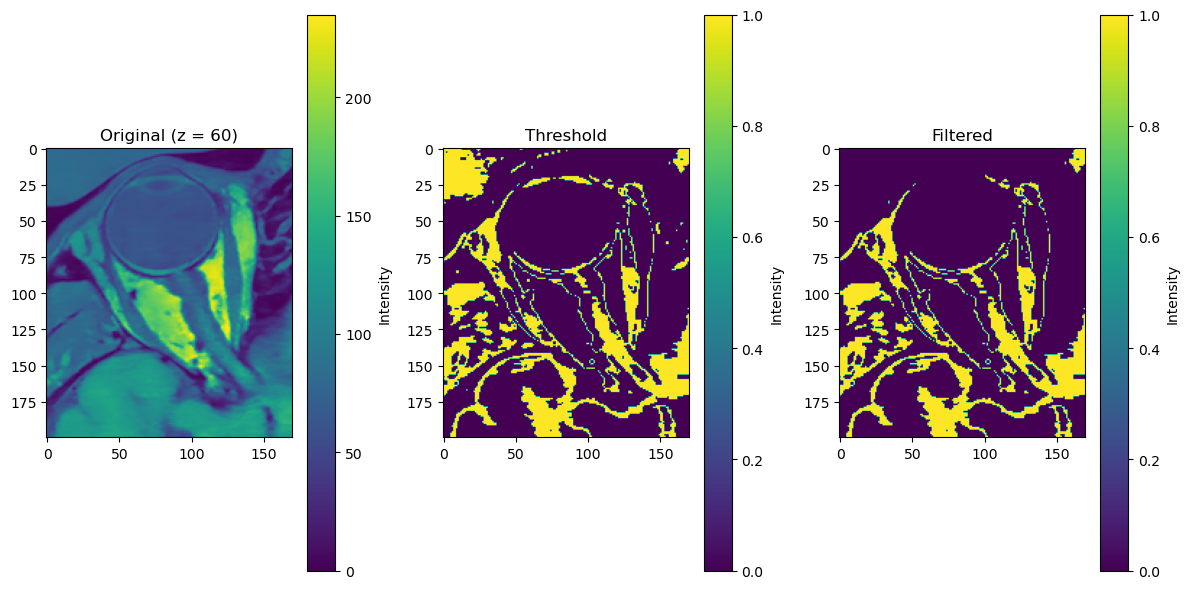

In [3]:
# %matplotlib widget
import matplotlib.pyplot as plt

mid_z = img.shape[2] // 2

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 6))

# first image
im1 = ax1.imshow(img[:, :, mid_z], cmap="viridis")
ax1.set_title(f"Original (z = {mid_z})")
cbar1 = fig.colorbar(im1, ax=ax1)
cbar1.set_label("Intensity")

# second image (filtered image)
im2 = ax2.imshow(mask[:, :, mid_z], cmap="viridis")
ax2.set_title("Threshold")
cbar2 = fig.colorbar(im2, ax=ax2)
cbar2.set_label("Intensity")

# second image (filtered image)
im3 = ax3.imshow(labels_mask[:, :, mid_z], cmap="viridis")
ax3.set_title("Filtered")
cbar3 = fig.colorbar(im3, ax=ax3)
cbar3.set_label("Intensity")

plt.tight_layout()
plt.show()


In [5]:
from scipy import ndimage
from nanomesh import Image
from nanomesh import Volume
from nanomesh import Mesher



# mask = np.zeros(img.shape, dtype=np.uint8)
# mask = ndimage.zoom(mask, 2)
# mask[mask<0.5]=0
# mask[mask>=0.5]=1

vol = Image(mask)


mesher = Mesher(vol)
mesher.generate_contour()

mesher.contour.region_markers

mesh = mesher.tetrahedralize(opts='-pAq -a50')


tetra_mesh = mesh.get('tetra')
tetra_mesh.write('test-2-cells.vtk')




Opening /var/folders/l0/d5k4byxx3690l9b12qr7mm440000gp/T/tmp27f51t__/nanomesh.smesh.
Delaunizing vertices...
Delaunay seconds:  5.28588
Creating surface mesh ...
Surface mesh seconds:  1.46302
Recovering boundaries...
Boundary recovery seconds:  6.97647
Removing exterior tetrahedra ...
Spreading region attributes.
Exterior tets removal seconds:  0.572716
Recovering Delaunayness...
Delaunay recovery seconds:  4.77356
Refining mesh...
Refinement seconds:  14.0473
Smoothing vertices...
Mesh smoothing seconds:  20.5353
Improving mesh...
Mesh improvement seconds:  1.35145

Writing /var/folders/l0/d5k4byxx3690l9b12qr7mm440000gp/T/tmp27f51t__/nanomesh.1.node.
Writing /var/folders/l0/d5k4byxx3690l9b12qr7mm440000gp/T/tmp27f51t__/nanomesh.1.ele.
Writing /var/folders/l0/d5k4byxx3690l9b12qr7mm440000gp/T/tmp27f51t__/nanomesh.1.face.
Writing /var/folders/l0/d5k4byxx3690l9b12qr7mm440000gp/T/tmp27f51t__/nanomesh.1.edge.

Output seconds:  4.99285
Total running seconds:  60.033

Statistics:

  Input poi